# Musterlösung 5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Kovarianz und Korrelationskoeffizient

In dieser Übung berechnen Sie die Kovarianz und den Korrelationskoeffizienten zwischen verschiedenen Messgrössen eines Datensatzes.

## a)

Laden Sie den Datensatz "data_xyz.txt". Er enthält drei Auslenkungen x, y und z, gemessen in Abhängigkeit der Zeit t. Erstellen Sie Plots der Messgrössen als Funktion der Zeit.

### Lösung

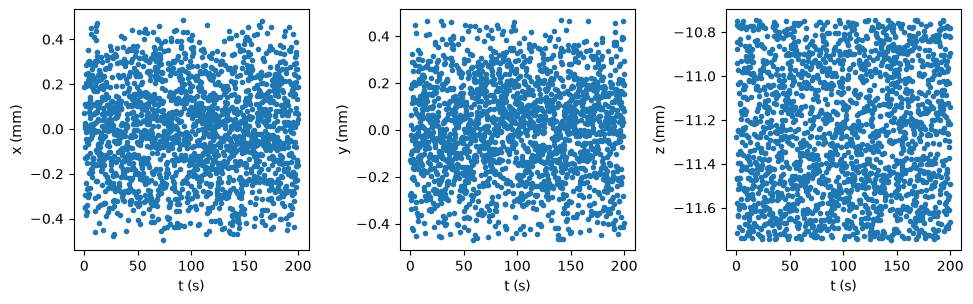

In [ ]:
# Daten einlesen
data = np.loadtxt('Ex05/data_xyz.txt', comments='#')

t = data[:, 0]
x = data[:, 1]
y = data[:, 2]
z = data[:, 3]

# Plots erstellen
cm = 1 / 2.54

fig = plt.figure(figsize=(25*cm, 8*cm))

ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(t, x, '.')
#ax1.plot(t, x)
ax1.set_xlabel('t (s)')
ax1.set_ylabel('x (mm)')

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(t, y, '.')
ax2.set_xlabel('t (s)')
ax2.set_ylabel('y (mm)')

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(t, z, '.')
ax3.set_xlabel('t (s)')
ax3.set_ylabel('z (mm)')


# Automatische Formatierung des Plot-Layouts, so dass keine Achsenbeschriftungen und Plots überlappen
fig.tight_layout()

Aus den Plots kann man keine Struktur erkennen. Alle drei Messgrössen scheinen zufällig um einen festen Wert zu fluktuieren.

## b)

Plotten Sie nun die Messgrössen paarweise in Abhängigkeit voneinander, also z.B. y(x), z(x) und y(z). Was sehen Sie für Abhängigkeiten?

Tipp: Verwenden Sie entweder die Funktion `ax.scatter` oder schalten Sie in `ax.plot` die Linien zwischen den Datenpunkten aus, um einen Scatterplot zu erstellen.

### Lösung

In [ ]:
cm = 1 / 2.54

fig = plt.figure(figsize=(25*cm, 8*cm))

ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(x, y, '.')
ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(x, z, '.')
ax2.set_xlabel('x (mm)')
ax2.set_ylabel('z (mm)')

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(y, z, '.')
ax3.set_xlabel('y (mm)')
ax3.set_ylabel('z (mm)')

fig.tight_layout()

Die Paare (x, z) und (y, z) sind unkorreliert, was man daran erkennt, dass die Punktewolke im Scatterplot keine ausgezeichnete Richtung aufweist. Das Paar (x, y) ist positiv korreliert: Wenn ein positiver x-Wert gemessen wurde, ist es wahrscheinlich, dass gleichzeitig auch ein positiver y-Wert gemessen wurde.

## c)

Schreiben Sie eine Funktion, die aus zwei gleich langen Arrays von Datenpunkten die Kovarianz berechnet.
Überprüfen Sie Ihr Resultat mithilfe von `np.cov`. Beachten Sie, dass diese Funktion die gesamte Kovarianzmatrix zurückgibt, also

$$ \mathrm{np.cov(x, y)} = \left( \begin{matrix} \sigma_{xx}^2 & \sigma_{xy}^2 \\
                                                 \sigma_{yx}^2 & \sigma_{yy}^2 \end{matrix} \right). $$

### Lösung

Als Referenz hier nochmal die Definition der Kovarianz aus der Vorlesung:

$$ \sigma_{xy}^2 = \mathrm{cov}(x, y) = \frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x}) (y_i - \bar{y}).$$


In [5]:
def covariance(x, y):
    '''Calculate covariance of two arrays x and y with same lengths.'''
    # Um Fehler zu vermeiden, können wir vorneweg testen, ob x und y wirklich die gleiche Länge haben
    if len(x) != len(y):
        raise ValueError('x and y must have same length.')
        
    N = len(x)
    
    # Zuerst Berechnen wir die Mittelwerte von x und y.
    # Hier könnten Sie auch np.mean oder Ihre Funktion aus Übung 2 verwenden.
    x_sum = 0
    y_sum = 0
    for i in range(N):
        x_sum += x[i]
        y_sum += y[i]
    
    x_mean = x_sum / N
    y_mean = y_sum / N
    
    # Als nächstes implementieren wir die Summe der Differenzen zum Mittelwert, wie in der Definition.
    cov_sum = 0
    for i in range(N):
        cov_sum += (x[i] - x_mean) * (y[i] - y_mean)
    
    # Duch N dividieren und zurückgeben
    return cov_sum / N


cov_np = np.cov(x, y)[0, 1]
cov_fct = covariance(x, y)
print('Mit der eigenen Funktion: sigma_xy = {:.3f} mm^2\n'
      'Mit np.cov:               sigma_xy = {:.3f} mm^2'.format(cov_fct, cov_np))

Mit der eigenen Funktion: sigma_xy = 0.014 mm^2
Mit np.cov:               sigma_xy = 0.014 mm^2


## d)

Berechnen Sie aus den Kovarianzen die Korrelationskoeffizienten für alle Kombinationen von x, y und z. Entspricht das Resultat Ihren Erwartungen aufgrund der Plots?

Sie können Ihr Resultat mithilfe von `np.corrcoef` überprüfen. Kleine Abweichungen können aufgrund von Rundungsfehlern und der genauen Implementation auftreten. Auch diese Funktion gibt gleich die ganze Korrelationsmatrix zurück.

### Lösung

Die Definition des Korrelationskoeffizienten ist:

$$\rho_{xy} = \frac{\mathrm{cov}(x, y)}{\sigma_x \sigma_y}.$$

In [ ]:
# Da sigma_x = sqrt(cov(x, x)) ist, können wir alles ausrechnen, ohne auf Numpy-Funktionen (ausser np.sqrt)
# zurückzugreifen. Wir machen das hier aus didaktischen Gründen. Wenn Sie Ihre Daten analysieren, ist es
# meistens empfehlenswert die Funktionen von Numpy zu verwenden, da diese optimiert sind und vor allem
# auf grossen Datensätzen viel schneller laufen.
sigma_x = np.sqrt(covariance(x, x))
sigma_y = np.sqrt(covariance(y, y))
sigma_z = np.sqrt(covariance(z, z))

rho_xy = covariance(x, y) / (sigma_x * sigma_y)
rho_xz = covariance(x, z) / (sigma_x * sigma_z)
rho_yz = covariance(y, z) / (sigma_y * sigma_z)

print('         Eigene Funktion   np.corrcoef')
print('rho_xy =     {:.3f}           {:.3f}'.format(rho_xy, np.corrcoef(x, y)[0, 1]))
print('rho_xz =    {:.3f}          {:.3f}'.format(rho_xz, np.corrcoef(x, z)[0, 1]))
print('rho_yz =     {:.3f}           {:.3f}'.format(rho_yz, np.corrcoef(y, z)[0, 1]))

         Eigene Funktion   np.corrcoef
rho_xy =     0.324           0.324
rho_xz =    -0.015          -0.015
rho_yz =     0.015           0.015


Die Korrelationskoeffizienten bestätigen die Annahme, dass $(x,y)$ positiv korreliert sind, während $(x,z)$ und $(y,z)$ unkorreliert sind. Natürlich sind Daten nie perfekt korreliert oder unkorreliert und die Koeffizienten können immer einen kleinen Wert annehmen.

# Autokovarianz als Funktion der Zeit

In dieser Übung schauen Sie sich die Autokovarianz verschiedener Arten von Signalen an.

## a)

Laden Sie den Datensatz 'signal_1.txt' und plotten Sie die Daten.

### Lösung

Text(0, 0.5, 'Amplitude (mV)')

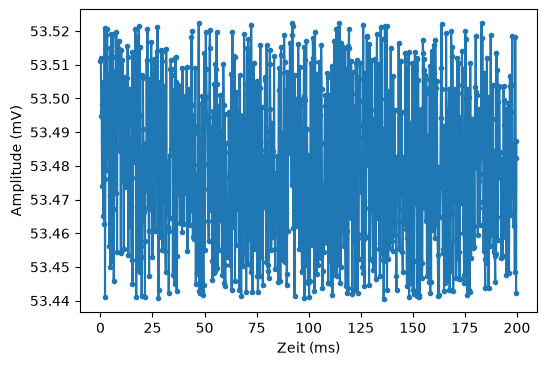

In [7]:
# Daten laden
data = np.loadtxt('Ex05/signal_1.txt', comments='#')
t = data[:, 0]
amplitude = data[:, 1]

# Plotten
cm = 1 / 2.54
fig = plt.figure(figsize=(15*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.plot(t * 1e3, amplitude, '.-')
ax.set_xlabel('Zeit (ms)')
ax.set_ylabel('Amplitude (mV)')

## b)

Schreiben Sie eine Funktion, die die Autokovarianz 

$$R_{xx}(\Delta i) = \frac{1}{N - \Delta i} \sum_{i=0}^{N - \Delta i - 1} \left(x[i] - \bar{x}\right) \left(x[i + \Delta i] - \bar{x}\right)$$

eines Datenarrays $x$ mit $N$ Punkten berechnet, die in gleichmässigen Zeitabständen gemessen wurden. Die Funktion soll zwei Arguemente haben, das Datenarray $x$, und die Verschiebung $\Delta i$. Folgendes ist zu beachten:

- Die Verschiebung $\Delta i$ gibt hier an, um wie viele Stellen der Arrayindex verschoben wird. Die entsprechende zeitliche Verschiebung ist $\tau = t[\Delta i] - t[0]$, wenn $t$ das Array für die Zeitachse ist.
- Die Summe geht von 0 bis $N - \Delta i - 1$, damit der Arrayindex $i + \Delta i$ immer kleiner als $N$ ist.
- Im Nenner steht dementsprechend $N - \Delta i$, da dies die Anzahl Terme in der Summe ist.

### Lösung

In [8]:
def auto_covariance(x, delta):
    '''Calculate the autocovariance of the array x with index shift delta.'''
    N = len(x)
    
    # Um Fehler zu vermeiden, können wir prüfen, ob delta < N ist.
    if delta >= N:
        raise ValueError("Delta must be smaller than len(x).")
        
    # Berechne den Mittelwert. Wir verwenden hier np.mean, man könnte es natürlich auch wieder
    # selber implementieren, wie in Aufgabe 1c).
    x_mean = np.mean(x)
    
    # Berechne die Summe laut Definition
    summation = 0
    for i in range(0, N - delta):
        summation += (x[i] - x_mean) * (x[i + delta] - x_mean)
    
    # Durch N - delta dividieren und zurückgeben
    return summation / (N - delta)

Diese Implementation ist einfach zu verstehen, aber wegen der for-Schleife für grosse Datensätze ziemlich langsam. Eine schnellere Implementation ist möglich, indem man ausnutzt, dass Operationen auf Numpy-Arrays elementweise ausgeführt werden können, was effizienter ist, als die Operationen in einer for-Schleife einzeln auszuführen. Zum Beispiel kann man den Mittelwert direkt vom ganzen Array subtrahieren:

```
x_mean = np.mean(x)
x_residue = x - x_mean
```

Um zu verstehen, wie die Summe über `x_residue[i] * x_residue[i + delta]` ohne for-Schleife berechnet werden kann, kann man sich die beiden Arrays mit verschobenem Index so vorstellen:

```
Index i                    0   1   2   ...  -5  -4  -3  -2  -1
x_residue[i]               | a | b | c | ... | v | w | x | y | z |
x_residue[i+delta] | a | b | c | d | e | ... | x | y | z |
```

wobei hier `delta = 2` ist. Um die Autokovarianz zu berechnen, müssen wir die Elemente, die hier übereinander stehen, miteinander multiplizieren und dann aufsummieren. Mit Array-Slicing wählen wir die relevanten Teilarrays aus,

```
x_residue[:-delta]   | a | b | c | ... | v | w | x |
x_residue[delta:]    | c | d | e | ... | x | y | z |
```

so dass wir die Multiplikation wieder direkt auf diesen ausführen können. Schliesslich verwenden wir noch die optimierte Numpy-Funktion `np.sum`, um die Summe der Produkte zu berechnen.

In [ ]:
def auto_covariance_fast(x, delta):
    # Den Fall delta = 0 müssen wir separat behandeln, weil x[:-0] ein leeres Array gibt.
    if delta == 0:
        autocov = np.var(x)
    else:
        N = len(x)
    
        # Wir subtrahieren erst den Mittelwert vom ganzen Array
        x_mean = np.mean(x)
        x_residue = x - x_mean
        
        # Durch Array-Slicing erhalten wir die relevanten überlappenden Teilarrays, von denen wir
        # den Mittelwert subtrahieren. Da wir mit Numpy-Arrays arbeiten, wird die anschliessende
        # Multiplikation elementweise durchgeführt. Die Elemente des resultierenden Arrays werden
        # mit np.sum effizient aufsummiert.
        autocov = np.sum(x_residue[:-delta] * x_residue[delta:]) / (N - delta)
        
    return autocov

## c)

Benutzen Sie Ihre Funktion, um die Autokovarianz des Amplitudensignals aus den geladenen Daten für jedes $\Delta = 0, \dots, N-1$ zu berechnen. Berechnen Sie auch die entsprechenden Zeitverschiebungen $\tau$ und plotten sie $R_{xx}(\tau)$. Interpretieren Sie das Resultat.


### Lösung

In [ ]:
N = len(amplitude)  # Anzahl Datenpunkte
dt = t[1] - t[0]  # Zeitdifferenz zwischen zwei Datenpunkten.
tau = np.arange(N-1) * dt  # Tau-Achse für die Autokovarianz

# Initialisiere ein leeres Array mit der richtigen Länge für die Autokovarianz als Funktion von tau oder delta
r_xx = np.zeros(N-1)
r_xxx = np.zeros(N-1)

# Berechne die Autokovarianz für jedes delta.
for delta in range(N-1):
    r_xx[delta] = auto_covariance_fast(amplitude, delta)
    r_xxx[delta] = auto_covariance(amplitude, delta)
print(np.where(r_xx-r_xxx < 0.00001, 0, r_xx-r_xxx))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

Text(0, 0.5, 'Autokovarianz $R_{xx}$ (mV$^2$)')

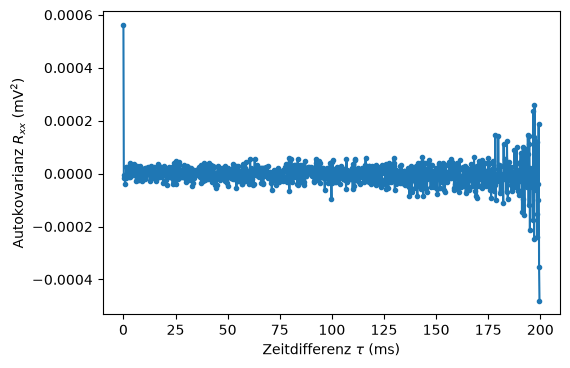

In [19]:
# Resultat plotten
cm = 1 / 2.54
fig = plt.figure(figsize=(15*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.plot(tau * 1e3, r_xx, '.-')
ax.set_xlabel('Zeitdifferenz $\\tau$ (ms)')
ax.set_ylabel('Autokovarianz $R_{xx}$ (mV$^2$)')

Wir sehen, dass die Autokovarianz immer Null ist, ausser bei $\tau = 0$, wo sie der Varianz entspricht $R_{xx}(\tau = 0) = \sigma_{x}^2$. Bei grossen $\tau$ wird die statistische Fluktuation gross, da die Autokovarianz nur noch aus sehr wenigen Punkten berechnet wird ($N - \Delta i$ nähert sich Null an).

Wenn die Autokovarianz überall Null ist, heisst das, dass die Daten zeitlich unkorreliert sind: Der gemessene Wert zu jedem Zeitpunkt ist unabhängig von den Werten zu allen anderen Zeiten. Das betrachtete physikalische System hat keine Erinnerung an seinen Zustand in der Vergangenheit.

## d)

Laden Sie nun den Datensatz 'signal_2.txt' und plotten Sie sowohl die Amplitude als Funktion der Zeit, als auch die Autokovarianz als Funktion von $\tau$. Interpretieren Sie wieder das Resultat.

### Lösung

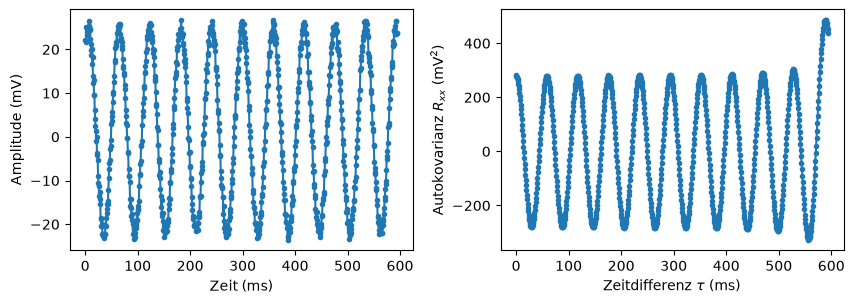

In [ ]:
# Daten laden
data = np.loadtxt('Ex05/signal_2.txt', comments='#')
t = data[:, 0]
amplitude = data[:, 1]

# Autokovarianz
N = len(amplitude)  # Anzahl Datenpunkte
dt = t[1] - t[0]  # Zeitdifferenz zwischen zwei Datenpunkten
tau = np.arange(N-1) * dt  # Tau-Achse für die Autokovarianz
r_xx = np.zeros(N-1)
for delta in range(N-1):
    r_xx[delta] = auto_covariance_fast(amplitude, delta)

# Plotten
cm = 1 / 2.54
fig = plt.figure(figsize=(22*cm, 8*cm))
ax = fig.add_subplot(1, 2, 1)
ax.plot(t * 1e3, amplitude, '.-')
ax.set_xlabel('Zeit (ms)')
ax.set_ylabel('Amplitude (mV)')

ax = fig.add_subplot(1, 2, 2)
ax.plot(tau * 1e3, r_xx, '.-')
ax.set_xlabel('Zeitdifferenz $\\tau$ (ms)')
ax.set_ylabel('Autokovarianz $R_{xx}$ (mV$^2$)')

fig.tight_layout()

Im zeitabhängigen Signal sieht man eine einfache Oszillation. Die Autokorrelation oszilliert ebenfalls, was leicht zu verstehen ist: Immer wenn die Zeitdifferenz $\tau$ ganzzahligen Vielfachen der Oszillationsperiode $T$ enspricht, also $\tau = k \cdot T$ mit $k \in \mathbb{Z}$, überlappt die Oszillation mit sich selbst und alle Summanden in der Autokorrelation sind positiv. Wenn aber $\tau = \left(k + \frac{1}{2}\right) \cdot T$, oszillieren das originale und verschobene Signal genau gegenphasig und alle Summanden sind negativ. Im Plot unten sind diese beiden Fälle dargestellt.

Da das System eine regelmässige Zeitabhängigkeit hat, sind die Messwerte nicht mehr zeitlich unabhängig voneinander: Wenn zum Zeitpunkt $t$ ein positiver Wert gemessen wird, wird auch eine Periode später bei $t + T$ ein positiver Wert auftreten; bei $t + T/2$ wird dagegen ein negativer Wert auftreten. Die Werte sind in diesem Fall also zeitlich korelliert, und zwar für beliebig lange Zeitdifferenzen $\tau$.

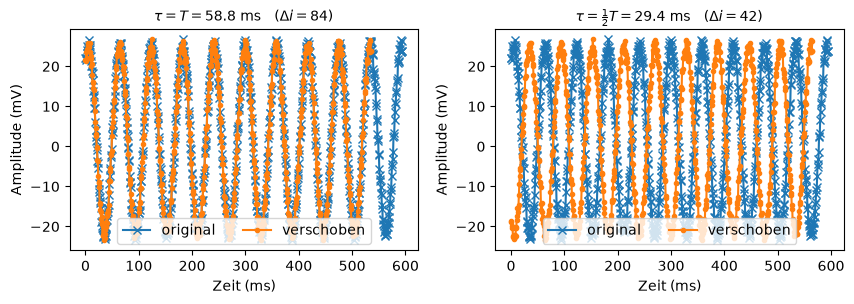

In [25]:
di_1 = 84
di_2 = 42

cm = 1 / 2.54
fig = plt.figure(figsize=(22*cm, 8*cm))
ax = fig.add_subplot(1, 2, 1)
ax.plot(t * 1e3, amplitude, 'x-', label='original')
ax.plot(t[:-di_1] * 1e3, amplitude[di_1:], '.-', label='verschoben')
ax.set_xlabel('Zeit (ms)')
ax.set_ylabel('Amplitude (mV)')
ax.set_title('$\\tau = T = {:.1f}$ ms   $(\\Delta i = {})$'.format(tau[di_1]*1e3, di_1), size=10)
ax.legend(ncol=2, loc='lower center')

ax = fig.add_subplot(1, 2, 2)
ax.plot(t * 1e3, amplitude, 'x-', label='original')
ax.plot(t[:-di_2] * 1e3, amplitude[di_2:], '.-', label='verschoben')
ax.set_xlabel('Zeit (ms)')
ax.set_ylabel('Amplitude (mV)')
ax.set_title('$\\tau = \\frac{{1}}{{2}} T = {:.1f}$ ms   $(\\Delta i = {})$'.format(tau[di_2]*1e3, di_2),
             size=10)
ax.legend(ncol=2, loc='lower center')

fig.tight_layout()

## e)

Laden Sie nun den letzten Datensatz, 'signal_3.txt'. Dieser enthält zwei zeitabhängige Messungen, die mit der gleichen Zeitachse gemessen wurden. Plotten Sie beide Signale als Funktion der Zeit und zoomen Sie in der Zeitachse, um die Struktur der Daten anzuschauen und sich den Unterschied zwischen den zwei Messungen bewusst zu machen.

### Lösung

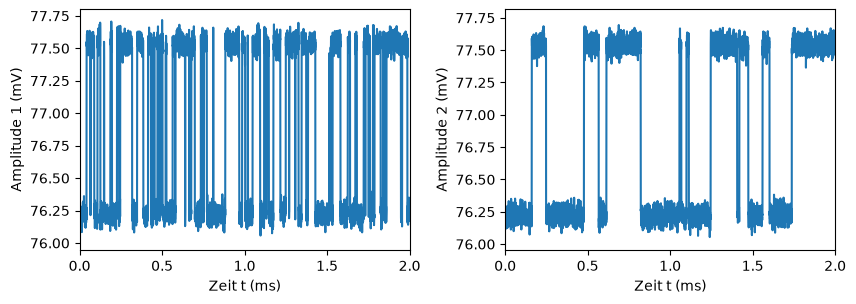

In [26]:
data = np.loadtxt('Ex05/signal_3.txt', comments='#')

t = data[0]
amplitude1 = data[1]
amplitude2 = data[2]

cm = 1 / 2.54
fig = plt.figure(figsize=(22*cm, 8*cm))
ax = fig.add_subplot(1, 2, 1)
ax.plot(t, amplitude1)
ax.set_xlabel('Zeit t (ms)')
ax.set_ylabel('Amplitude 1 (mV)')

ax.set_xlim(0, 2)


ax = fig.add_subplot(1, 2, 2)
ax.plot(t, amplitude2)
ax.set_xlabel('Zeit t (ms)')
ax.set_ylabel('Amplitude 2 (mV)')

ax.set_xlim(0, 2)

fig.tight_layout()

Beide Messungen zeigen Sprünge zwischen zwei Werten auf, aber die Häufigkeit der Sprünge ist in der zweiten Messung kleiner.

## f)

Aus Ihren Plots sollten Sie für jede Messung eine typische Zeitskala $T_{\mathrm{sys}}$ ablesen können, die für das jeweilige System relevant ist. Da diese Messungen sehr viele Datenpunkte haben, kann die Ausführung des Codes sehr lange dauern, wenn Sie die Autokovarianz wie oben für alle möglichen $\tau$ bis $T_{\mathrm{max}}$ berechnen. Berechnen Sie deswegen die Autokovarianz beider Signale nur für $\tau \in [0, 2 T_{\mathrm{sys}}]$; der genaue Wert der oberen Grenze ist nicht so wichtig, nur dass er etwas grösser als die längere typische Zeitskala $T_{\mathrm{sys}}$ ist. Dass Sie die obere Grenze hinreichend gross gewählt haben, erkennen Sie daran, dass die Autokovarianz für grosse $\tau$ gegen Null geht.

Vergleichen Sie die beiden Autokovarianzen und erklären Sie die Beziehung zu der Struktur, die Sie im zeitabhängigen Signal gesehen haben.

Tipp: Wenn die Fehlersuche mühsam ist, weil die Ausführung des Codes zu lange dauert, nehmen Sie erst mal nur die ersten 1000 Datenpunkte.

### Lösung

Die typische Zeitskala, auf der die langsameren Sprünge in der zweiten Messung stattfinden, ist etwa 0.25 ms., daher wählen wir als obere Grenze 0.5 ms.

In [27]:
# Tau-Achse
dt = t[1] - t[0]  # Zeitdifferenz zwischen zwei Datenpunkten.
tau_max = 0.5
tau = np.arange(0, tau_max, dt)

# Initialisiere Arrays für die Autokovarianzen
r_xx1 = np.zeros(len(tau))
r_xx2 = np.zeros(len(tau))

# Autokovarianz berechnen
# Das delta zu jedem tau ist jetzt einfach sein Arrayindex.
for delta in range(len(tau)):
    r_xx1[delta] = auto_covariance_fast(amplitude1, delta)
    r_xx2[delta] = auto_covariance_fast(amplitude2, delta)

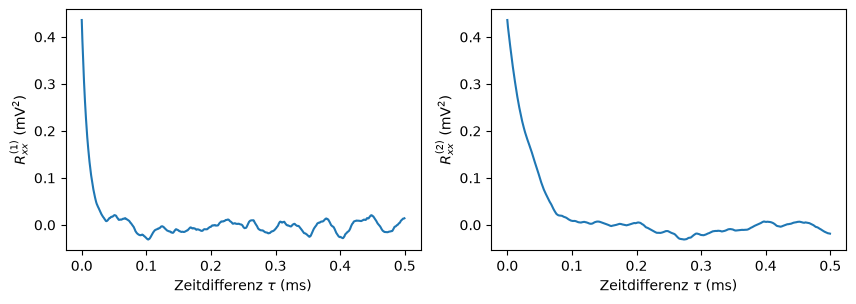

In [28]:
# Autokovarianz plotten
cm = 1 / 2.54
fig = plt.figure(figsize=(22*cm, 8*cm))
ax = fig.add_subplot(1, 2, 1)
ax.plot(tau, r_xx1)
ax.set_xlabel('Zeitdifferenz $\\tau$ (ms)')
ax.set_ylabel('$R_{xx}^{(1)}$ (mV$^2$)')

ax = fig.add_subplot(1, 2, 2)
ax.plot(tau, r_xx2)
ax.set_xlabel('Zeitdifferenz $\\tau$ (ms)')
ax.set_ylabel('$R_{xx}^{(2)}$ (mV$^2$)')

fig.tight_layout()

Wie man sieht, war die obere grenze von $\tau = 0.5$ s gross genug gewählt, da die Autokovarianz hier schon Null wird (mit ein wenig Rauschen). Auf kurzen Zeitskalen $\tau < 0.1$ s passiert etwas. Zum besseren Vergleich plotten wir die beiden Kurven zusammen und zoomen auf kleine $\tau$.

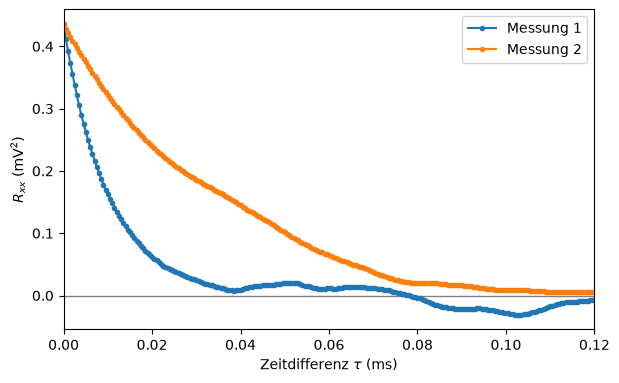

In [29]:
cm = 1 / 2.54
fig = plt.figure(figsize=(16*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)

ax.axhline(0, color='.5', linewidth=1)

ax.plot(tau, r_xx1, '.-', label='Messung 1')
ax.plot(tau, r_xx2, '.-', label='Messung 2')

ax.set_xlabel('Zeitdifferenz $\\tau$ (ms)')
ax.set_ylabel('$R_{xx}$ (mV$^2$)')
ax.legend()

ax.set_xlim(0.0, 0.12)

fig.tight_layout()

Man sieht, dass die Autokovarianz beider Messungen für kleine $\tau$ grösser als Null bleibt. Die charakteristische Zeit, in der die Autokovarianz auf Null abfällt unterscheidet sich allerdings: Messung 1 fällt schneller ab ($\tau_c \approx 0.02$ ms) als Messung 2 ($\tau_c \approx 0.07$ ms). Das passt mit der Beobachtung aus den zeitabhängigen Signalen zusammen: In Messung 1 springt das System schneller zwischen den zwei Zuständen hin und her, d.h. schon kurze Zeit nach der Messung eines hohen Werts (77.5 mV) ist es wieder gleich wahrscheinlich, das System in beiden Zuständen zu finden. In Messung 2 sind die Sprünge seltener, d.h. das System "erinnert" sich für eine längere Zeit daran, in welchem Zustand es gerade war, was sich in der Autokorrelation wiederspiegelt.

In diesem Fall erlaubt uns die Autokovarianz die Beobachtung "in Messung 1 sind die Sprünge häufiger" zu quantifizieren, nämlich mit der charakteristischen Zeit $\tau_c$ (Korrelationszeit).